In [2]:
import numpy as np
import pandas as pd
import os 
import sys

# todo
from preprocess.spikesort_utils import remove_stim_events, ks4_preprocess, split_by_stim, get_global_spikes, load_ks4_sorting, split_templates_by_shank
sys.path.append("..//neural")
from format_waveform_data import map_contacts_to_intan
sys.path.append("..//utils")
import load_matlab_data

import spikeinterface as si # core only
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.sorters as ss
import spikeinterface.exporters as sexp
from spikeinterface.core.motion import Motion
from spikeinterface.sortingcomponents.motion import interpolate_motion

from probeinterface import get_probe

import dartsort

import probeinterface.plotting as prb_plotting
import spikeinterface.widgets as sw
import dartsort.vis as dartvis
import matplotlib.pyplot as plt

In [3]:
''' File paths '''
root_dir = "C:/Users/Isabel/Documents/data_temp/"

# session params
bird_id = "SLV132"
session_id = "250310"
ephys_id = "SLV132_250310_122522"

# path to .rhd intan file
intan_folder = f"{root_dir}{bird_id}_{session_id}/{ephys_id}/"

# path to various info files
map_file_path = 'Z:/Isabel/ephys/SILICON PROBE MAP H10_spikesort.xlsx'
stim_data_file = f"{intan_folder}raw_ephys_output/stim_t_all.npy"

# output folders for kilosort, dartsort, and phy
ks_folder = f"{intan_folder}kilosort_si/"
ds_folder = f"{intan_folder}dartsort/"
if os.path.isdir(ds_folder):
    print('output folder exists')
else:
    os.mkdir(ds_folder)

In [4]:
''' Load the recording file '''
# raw neural data
recording = se.read_intan(f"{intan_folder}info.rhd", stream_id='0')

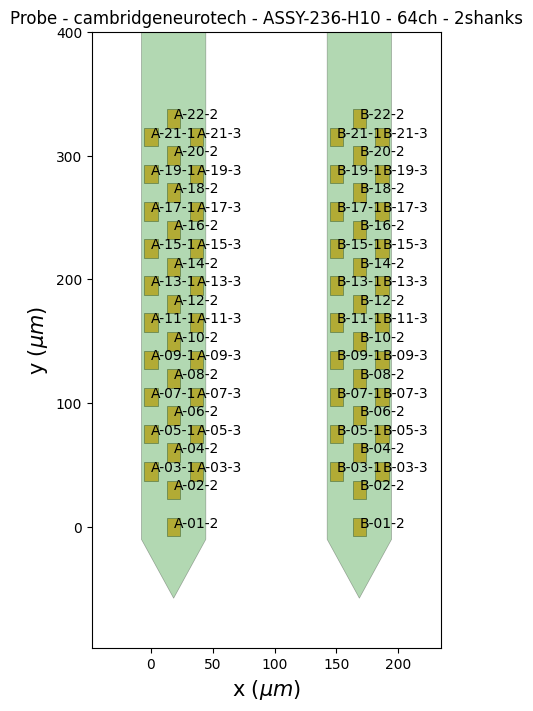

In [5]:
''' Add the probe map and check channel layout '''
# load the probe layout
probe = get_probe(manufacturer="cambridgeneurotech", probe_name="ASSY-236-H10")

# map to intan
contact_sort, ch_names, shank_idx = map_contacts_to_intan(probe, map_file_path)
probe = probe.get_slice(contact_sort)

# visualize to check
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
prb_plotting.plot_probe(probe, ax=ax)
ylims = ax.get_ylim()
ax.set_ylim(ylims[0], 400)
for pos, ch_name in zip(probe.contact_positions, ch_names):
    ax.text(pos[0], pos[1], ch_name)

In [6]:
# set the channel indices in the probe object
n_channels = contact_sort.shape[0]
probe.set_device_channel_indices(np.arange(n_channels))

# add the probe map
recording = recording.set_probe(probe)
recording.set_property("channel_name", ch_names)
recording.set_property("group", shank_idx)

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

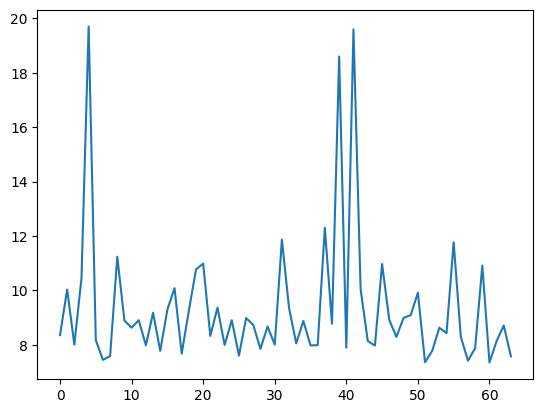

In [7]:
# check for noisy channels
noise_level = si.get_noise_levels(spre.common_reference(spre.highpass_filter(recording)))
plt.plot(noise_level) # set noise thresh

In [8]:
# set noise threshold and remove noisy channels
noise_thresh = 16
keep_ch_idx = noise_level < noise_thresh
recording = recording.select_channels(recording.channel_ids[keep_ch_idx])

In [9]:
# sanity check and channel count
print(recording.get_num_channels())
print(recording.get_property("group").shape)
print(recording.get_property("channel_name").shape)
print(recording.get_channel_locations().shape)

61
(61,)
(61,)
(61, 2)


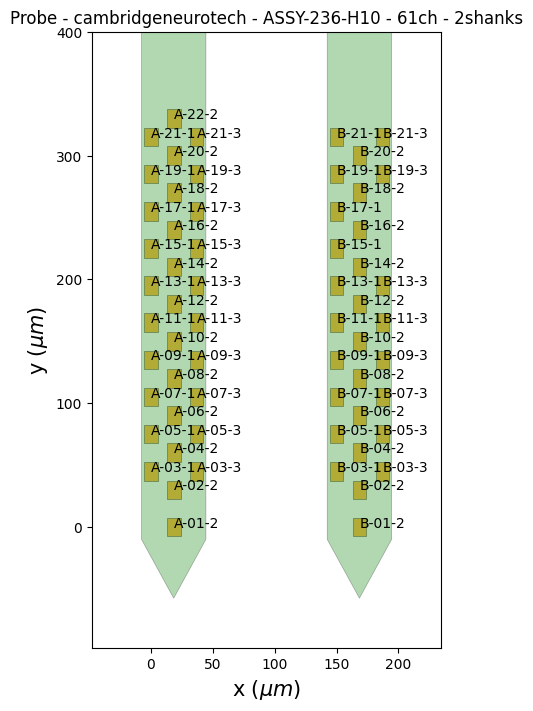

In [10]:
# reset the probe device indices
probe = recording.get_probe()
probe.set_device_channel_indices(
    np.arange(probe.get_contact_count())
)

# visualize to check
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
prb_plotting.plot_probe(probe, ax=ax)
ylims = ax.get_ylim()
ax.set_ylim(ylims[0], 400)
for pos, ch_name in zip(probe.contact_positions, recording.get_property("channel_name")):
    ax.text(pos[0], pos[1], ch_name)

In [11]:
recording = recording.set_probe(probe)
assert (recording.get_num_channels() == recording.get_probe().get_contact_count())

Order of operations:
- find stim times and remove stim events
--> 200us + 6 sample buffer before and after
- motion correction (si function and widget to visualize and check)
- preprocess for dartsort (bandpass, CMR, whitening)
- split the data into spontaneous and stim chunks (preprocessed and not) using stim times

- sort spontaneous w/ kilosort (motion corrected, not preprocessed recording) *motion correction turned off*
- convert ks output to ds and estimate low-rank templates (motion corrected, preprocessed recording) *whitening turned off*
- match templates to spontaneous data for baseline match scores
- match templates to stim data (motion corrected, preprocessed recording) *whitening turned off*
- concatenate spike times, labels, scores and export for phy

In [14]:
''' Find and remove stim event times '''
# load the saved stim times
stim_t_samples = np.load(stim_data_file)
stim_t_samples = np.squeeze(stim_t_samples.astype(int))

# remove stim events + buffer
rec_no_stim, mask_starts, mask_duration = remove_stim_events(recording, stim_t_samples)

In [15]:
''' Bandpass filter and common median referencing '''
rec_filt_cmr = ks4_preprocess(rec_no_stim, filt=True, cmr=True, whiten=False)

In [17]:
''' Estimate drift and plot to check '''
if os.path.isfile(f'{intan_folder}motion_estimate'):
    # load pre-existing motion info
    motion = Motion.load(f'{intan_folder}motion_estimate')
    motion_info = np.load(f'{intan_folder}motion_info.npz')
else:
    # compute motion estimate and info
    motion, motion_info = spre.compute_motion(
        rec_filt_cmr,
        preset="nonrigid_accurate",
        output_motion_info=True,
    )
    
    # save for later
    motion.save(f'{intan_folder}motion_estimate')
    np.savez(f'{intan_folder}motion_info.npz', 
             peaks=motion_info["peaks"], peak_locations=motion_info["peak_locations"])

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

detect and localize (no parallelization):   0%|          | 0/2740 [00:00<?, ?it/s]

C:\Users\Isabel\miniconda3\envs\spike_sort\Lib\site-packages\spikeinterface\sortingcomponents\motion\motion_utils.py:82: UserWarning: You are trying to estimate motion with `non-rigid` on a probe that is too short!get_spatial_windows(): win_step_um=200.0/win_scale_um=300.0/win_margin_um=-150.0 are too large for the probe size (depth range=330.0). Switching to rigid motion.
  warnings.warn(


pairwise displacement:   0%|          | 0/2 [00:00<?, ?it/s]

TypeError: MotionInfoWidget.__init__() missing 1 required positional argument: 'recording'

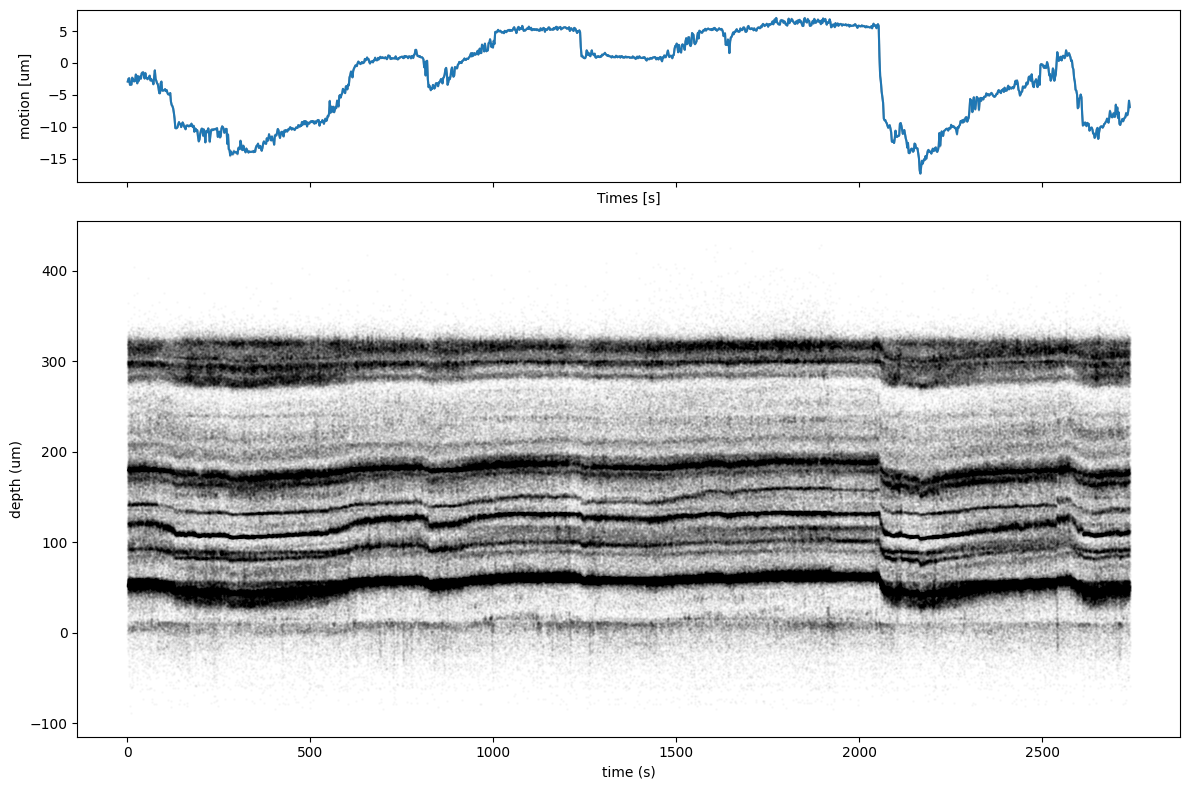

In [28]:
# data params
peak_times = (motion_info["peaks"]["sample_index"]/rec_filt_cmr.get_sampling_frequency())
depths = motion_info["peak_locations"]["y"]

# fig params
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                               gridspec_kw={"height_ratios": [1, 3]})

# motion estimate
sw.plot_motion(motion, ax=ax0)

# peak localization scatter
ax1.scatter(peak_times, depths, c='k', s=1, alpha=0.02)
ax1.set_xlabel("time (s)")
ax1.set_ylabel("depth (um)")

plt.tight_layout()
plt.show()

In [31]:
''' Interpolate motion '''
from spikeinterface.sortingcomponents.motion import interpolate_motion
rec_mc = interpolate_motion(rec_filt_cmr, motion)

In [86]:
''' Separate pre- and post-stim periods '''
# define the post stim (hash) window
post_mask_t = 20e-3

# separate the recordings
recordings, maps = split_by_stim(rec_mc, mask_starts, mask_duration, post_mask_t=post_mask_t)

In [88]:
''' Save as binary files for kilosort '''
rec_pre_stim = recordings['pre_stim'].save(format="binary", folder=f"{ks_folder}pre_stim_binary_ii")
rec_post_stim = recordings['post_stim'].save(format="binary", folder=f"{ks_folder}post_stim_binary_ii")

write_binary_recording 
engine=process - n_jobs=1 - samples_per_chunk=30,000 - chunk_memory=3.49 MiB - total_memory=3.49 MiB - chunk_duration=1.00s


write_binary_recording (no parallelization):   0%|          | 0/2721 [00:00<?, ?it/s]

write_binary_recording 
engine=process - n_jobs=1 - samples_per_chunk=30,000 - chunk_memory=3.49 MiB - total_memory=3.49 MiB - chunk_duration=1.00s


write_binary_recording (no parallelization):   0%|          | 0/19 [00:00<?, ?it/s]

In [91]:
''' Sort the data without stim + hash '''
# skip motion correction
sort_pre_stim = ss.run_sorter(sorter_name="kilosort4", 
                              recording=rec_pre_stim, 
                              folder=ks_folder, 
                              torch_device='cuda', 
                              skip_kilosort_preprocessing=False,
                              nblocks=0,
                              verbose=True)

kilosort.run_kilosort:  
kilosort.run_kilosort: Computing preprocessing variables.
kilosort.run_kilosort: ----------------------------------------
kilosort.run_kilosort: N samples: 81613644
kilosort.run_kilosort: N seconds: 2720.4548
kilosort.run_kilosort: N batches: 1361
kilosort.run_kilosort: Preprocessing filters computed in 0.66s; total 0.66s
kilosort.run_kilosort:  
kilosort.run_kilosort: Resource usage after preprocessing
kilosort.run_kilosort: ********************************************************
kilosort.run_kilosort: CPU usage:     0.00 %
kilosort.run_kilosort: Mem used:     65.50 %     |      41.35 GB
kilosort.run_kilosort: Mem avail:    21.79 / 63.14 GB
kilosort.run_kilosort: ------------------------------------------------------
kilosort.run_kilosort: GPU usage:    `conda install pynvml` for GPU usage
kilosort.run_kilosort: GPU memory:   100.00 %     |     15.99   /    15.99 GB
kilosort.run_kilosort: Allocated:    11.15 %     |      1.78   /    15.99 GB
kilosort.run_kilo

kilosort4 run time 281.08s


C:\Users\Isabel\miniconda3\envs\spike_sort\Lib\site-packages\spikeinterface\core\basesorting.py:320: UserWarning: Some spikes exceed the recording's duration! Removing these excess spikes with `spikeinterface.curation.remove_excess_spikes()` Might be necessary for further postprocessing.
  warnings.warn(


In [92]:
''' Whiten and save the data for dartsort '''
rec_preprocessed = ks4_preprocess(rec_mc, filt=False, cmr=False, whiten=True)
recordings, maps = split_by_stim_temp(rec_preprocessed, mask_starts, mask_duration, post_mask_t=post_mask_t)
rec_pre_stim = recordings['pre_stim'].save(format="binary", folder=f"{ds_folder}pre_stim_binary")
rec_post_stim = recordings['post_stim'].save(format="binary", folder=f"{ds_folder}post_stim_binary")

write_binary_recording 
engine=process - n_jobs=1 - samples_per_chunk=30,000 - chunk_memory=3.49 MiB - total_memory=3.49 MiB - chunk_duration=1.00s


write_binary_recording (no parallelization):   0%|          | 0/2721 [00:00<?, ?it/s]

write_binary_recording 
engine=process - n_jobs=1 - samples_per_chunk=30,000 - chunk_memory=3.49 MiB - total_memory=3.49 MiB - chunk_duration=1.00s


write_binary_recording (no parallelization):   0%|          | 0/19 [00:00<?, ?it/s]

In [212]:
''' Estimate low-rank templates from KS4 sorting '''
# to realign KS templates
realign_ms = 1.5

# load the ks outputs as a dartsort object
ks_st, clu_group = load_ks4_sorting(rec_pre_stim, f"{ks_folder}/sorter_output/")

# turn off internal whitening
template_cfg = dartsort.TemplateConfig(whitening=dartsort.WhiteningConfig(strategy='none'))

# get the templates
ks_st_realigned, template_data = dartsort.estimate_template_library(
    recording=rec_pre_stim,
    sorting=ks_st,
    realign_cfg=dartsort.TemplateRealignmentConfig(realign_shift_ms=realign_ms),
    template_cfg=dartsort.default_template_cfg,
    template_npz_path=f"{ds_folder}/template_data.npz",
)

# save the realigned spike times
ks_st_realigned.save(f"{ds_folder}/ks_st_realigned.npz")

Raw templates:cuda 1.0s/it [spk/it=%%%]:   0%|          | 0/2721 [00:00<?, ?it/s]

Raw templates:cuda 1.0s/it [spk/it=%%%]:   0%|          | 0/2721 [00:00<?, ?it/s]

Templates:cuda 1.0s/it [spk/it=%%%]:   0%|          | 0/2721 [00:00<?, ?it/s]

Medians:cuda:4:   0%|          | 0/323 [00:00<?, ?it/s]

In [213]:
''' Temp workaround - split by shank '''
rec_post_stim_split = rec_post_stim.split_by("group")
shank_idx = rec_post_stim.get_property("group")
template_data_0, template_data_1 = split_templates_by_shank(ds_folder, template_data, shank_idx)

# confirm proper split
print(template_data.templates.shape)
print(template_data_0.templates.shape)
print(template_data_1.templates.shape)

(323, 121, 61)
(148, 121, 32)
(175, 121, 29)


In [214]:
''' Find templates in post-stim period '''
matching_cfg = dartsort.MatchingConfig(whitening=dartsort.WhiteningConfig(strategy="none"))

# A shank
post_stim_st_A = dartsort.match(
    recording=rec_post_stim_split[0],
    template_data=template_data_0,
    output_dir=f"{ds_folder}/post_stim_A_match",
    matching_cfg=matching_cfg,
    featurization_cfg=dartsort.FeaturizationConfig(tpca_from_templates=False)
)

# B shank
post_stim_st_B = dartsort.match(
    recording=rec_post_stim_split[1],
    template_data=template_data_1,
    output_dir=f"{ds_folder}/post_stim_B_match",
    matching_cfg=matching_cfg,
    featurization_cfg=dartsort.FeaturizationConfig(tpca_from_templates=False)
)

Load examples for feature fitting:cuda 1.0s/it [spk/it=%%%]:   0%|          | 0/19 [00:00<?, ?it/s]

Got 51685 spikes, enough to stop early.


/peeled_waveforms_fit:   0%|          | 0/51 [00:00<?, ?it/s]

Train localizer:   0%|          | 0/100 [00:00<?, ?epoch/s]

TemplateMatching:cuda 1.0s/it [spk/it=%%%]:   0%|          | 0/19 [00:00<?, ?it/s]

Load examples for feature fitting:cuda 1.0s/it [spk/it=%%%]:   0%|          | 0/19 [00:00<?, ?it/s]

Got 53223 spikes, enough to stop early.


/peeled_waveforms_fit:   0%|          | 0/52 [00:00<?, ?it/s]

Train localizer:   0%|          | 0/100 [00:00<?, ?epoch/s]

TemplateMatching:cuda 1.0s/it [spk/it=%%%]:   0%|          | 0/19 [00:00<?, ?it/s]

In [215]:
''' For comparison, get matching scores for spontaneous units '''
# take just the spontaneous spikes near stim events
pre_stim_map = maps['pre_stim']
before_stim_samples = pre_stim_map['snippet_dur'][0]
n_pre_stim_samples = rec_pre_stim.get_num_frames()
rec_pre_stim_subsamp = rec_pre_stim.frame_slice(start_frame=before_stim_samples, 
                                                end_frame=n_pre_stim_samples)

# split by shank for now
rec_pre_stim_split = rec_pre_stim_subsamp.split_by("group")

# A shank
pre_stim_st_A = dartsort.match(
    recording=rec_pre_stim_split[0],
    template_data=template_data_0,
    output_dir=f"{ds_folder}/pre_stim_A_match",
    matching_cfg=matching_cfg,
    featurization_cfg=dartsort.FeaturizationConfig(tpca_from_templates=False)
)

# B shank
pre_stim_st_B = dartsort.match(
    recording=rec_pre_stim_split[1],
    template_data=template_data_1,
    output_dir=f"{ds_folder}/pre_stim_B_match",
    matching_cfg=matching_cfg,
    featurization_cfg=dartsort.FeaturizationConfig(tpca_from_templates=False)
)

Load examples for feature fitting:cuda 1.0s/it [spk/it=%%%]:   0%|          | 0/1420 [00:00<?, ?it/s]

Got 53954 spikes, enough to stop early.


/peeled_waveforms_fit:   0%|          | 0/53 [00:00<?, ?it/s]

Train localizer:   0%|          | 0/100 [00:00<?, ?epoch/s]

TemplateMatching:cuda 1.0s/it [spk/it=%%%]:   0%|          | 0/1420 [00:00<?, ?it/s]

Load examples for feature fitting:cuda 1.0s/it [spk/it=%%%]:   0%|          | 0/1420 [00:00<?, ?it/s]

Got 52430 spikes, enough to stop early.


/peeled_waveforms_fit:   0%|          | 0/52 [00:00<?, ?it/s]

Train localizer:   0%|          | 0/100 [00:00<?, ?epoch/s]

TemplateMatching:cuda 1.0s/it [spk/it=%%%]:   0%|          | 0/1420 [00:00<?, ?it/s]

In [216]:
# get matching score distribution for each cell
spont_match_labels = np.concatenate([pre_stim_st_A.labels, pre_stim_st_B.labels])
spont_match_scores =  np.concatenate([pre_stim_st_A.scores, pre_stim_st_B.scores])
spont_ks_labels = ks_st_realigned.labels

spont_score_dist = []
for cell_id in np.unique(spont_ks_labels):
    if any(spont_match_labels==cell_id):
        spont_score_dist.append(spont_match_scores[spont_match_labels==cell_id])
    else:
        spont_score_dist.append([])

# get 5th percentile of each score distribution
pct5_score = np.full(len(spont_score_dist), np.nan)
for i, spont_scores in enumerate(spont_score_dist):
    if len(spont_scores) > 0:
        pct5_score[i] = np.percentile(spont_scores, 5)
np.save(f'{ds_folder}spont_scores_pct5.npy', pct5_score)

In [232]:
# filter out bad spikes
pre_spike_t_local = ks_st_realigned.times_samples
pre_spike_labels = ks_st_realigned.labels
pre_spike_t_local = pre_spike_t_local[pre_spike_labels >= 0]
pre_spike_labels = pre_spike_labels[pre_spike_labels >= 0]

# spike times and unit IDs (aligned to full recording)
pre_stim_map = maps['pre_stim']
post_stim_map = maps['post_stim']
pre_stim_times = get_global_spikes(pre_spike_t_local, pre_stim_map)
post_stim_times_A = get_global_spikes(post_stim_st_A.times_samples, post_stim_map)
post_stim_times_B = get_global_spikes(post_stim_st_B.times_samples, post_stim_map)

# unit IDs for each spike
post_stim_labels_A = post_stim_st_A.labels
post_stim_labels_B = post_stim_st_B.labels

# matching score (higher is better)
scores_A = post_stim_st_A.scores
scores_B = post_stim_st_B.scores

In [234]:
# get nan_idx (spikes falling outside recording window due to realignment)
keep_idx = ~np.isnan(pre_stim_times)
pre_stim_times = pre_stim_times[keep_idx]
spont_ks_labels = pre_spike_labels[keep_idx]

In [241]:
''' Concatenate the spike times and labels from each set of recording chunks '''
# concatenate
all_spike_t = np.concatenate([pre_stim_times, post_stim_times_A, post_stim_times_B])
all_spike_labels = np.concatenate([pre_spike_labels, post_stim_labels_A, post_stim_labels_B])
all_spike_scores = np.concatenate([np.full(spont_ks_labels.shape[0], np.nan), scores_A, scores_B])

# sort by time
sort_idx = np.argsort(all_spike_t)
all_spike_labels = all_spike_labels[sort_idx]
all_spike_scores = all_spike_scores[sort_idx]
all_spike_t = all_spike_t[sort_idx]

# create a Spike Interface sorting object to export to Phy
fs = rec_pre_stim.get_sampling_frequency()
combined_sorting = si.NumpySorting.from_samples_and_labels(
    samples_list=[all_spike_t],
    labels_list=[all_spike_labels],
    sampling_frequency=fs,
)
combined_sorting.set_property("ks_label", clu_group)

In [242]:
np.save(f'{ds_folder}match_scores.npy', all_spike_scores)

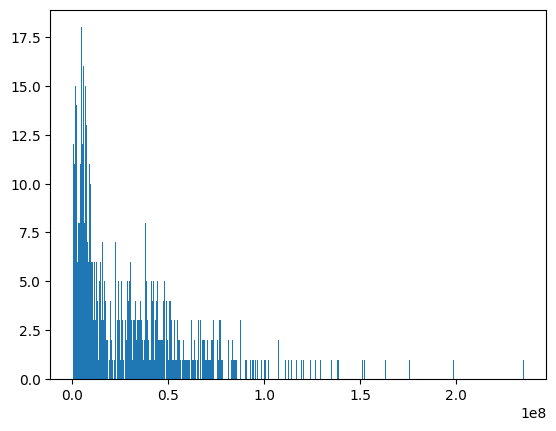

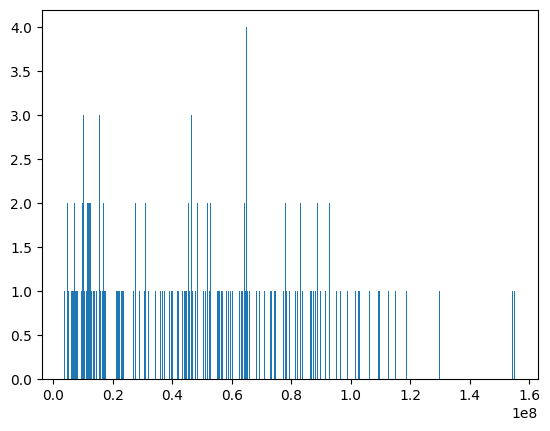

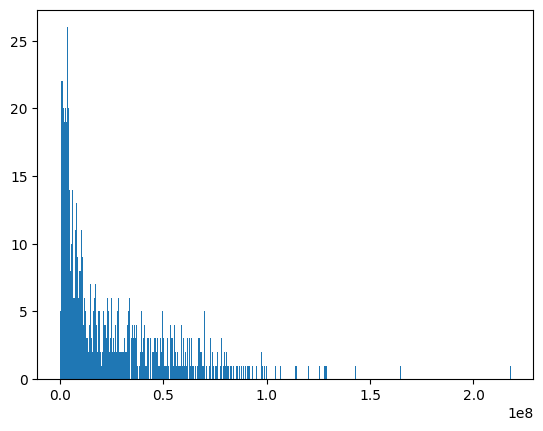

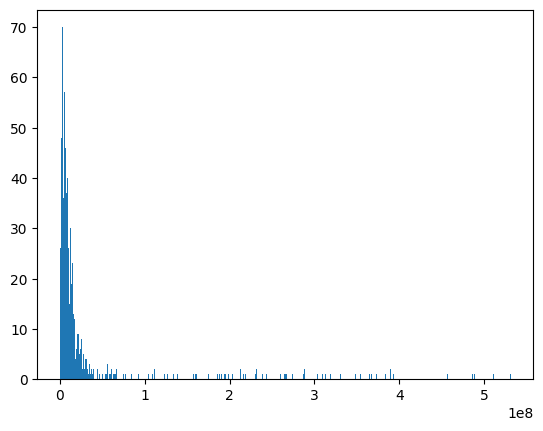

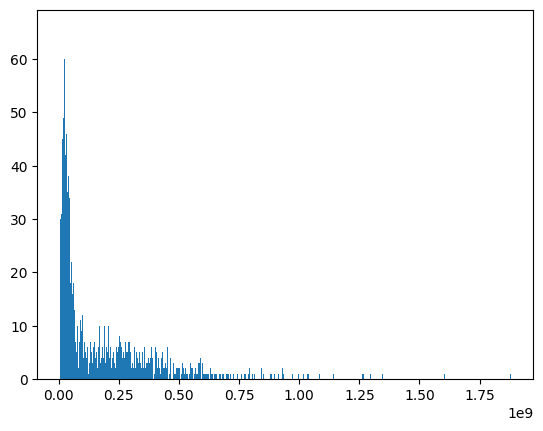

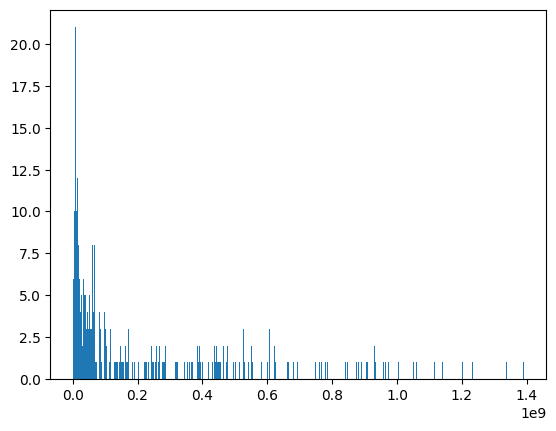

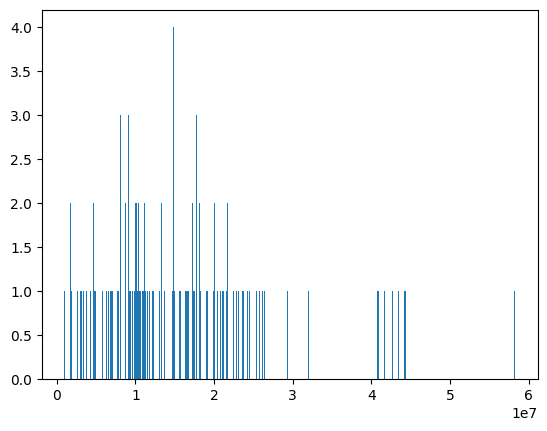

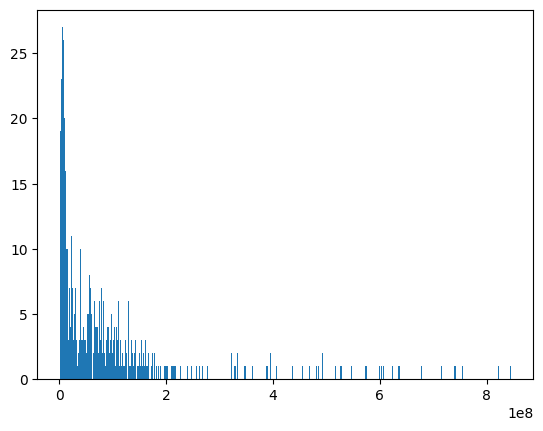

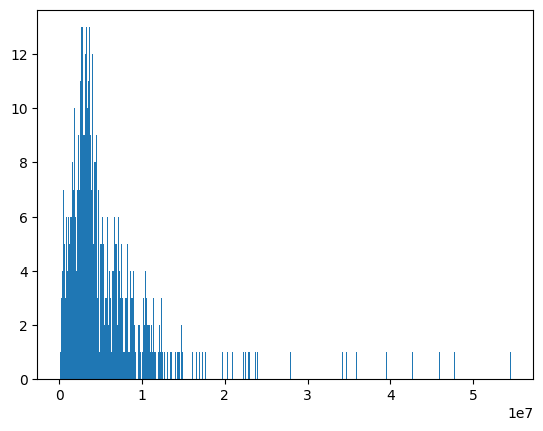

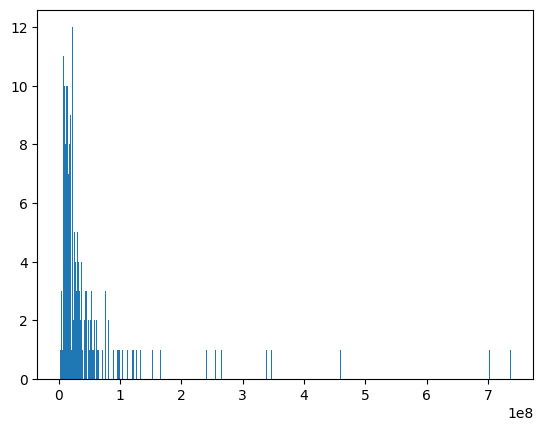

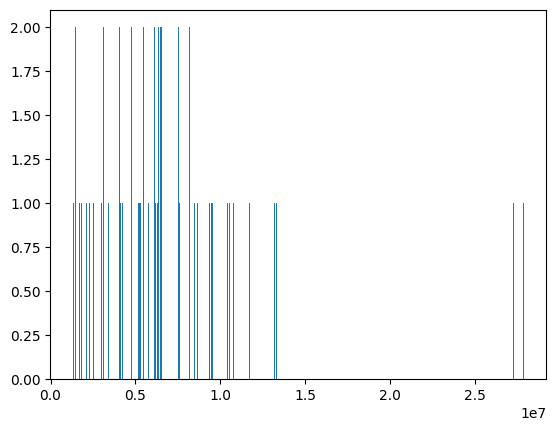

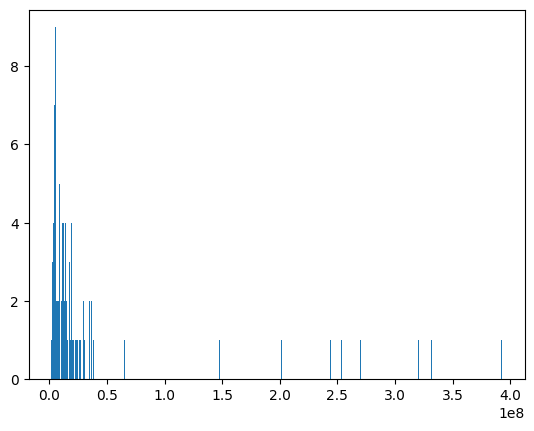

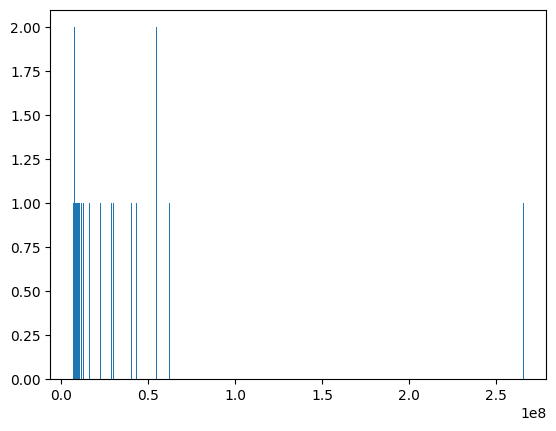

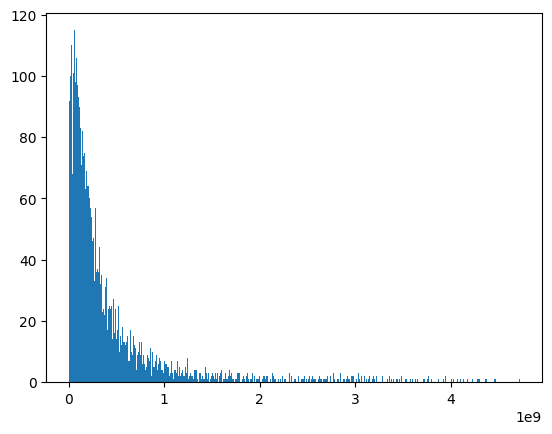

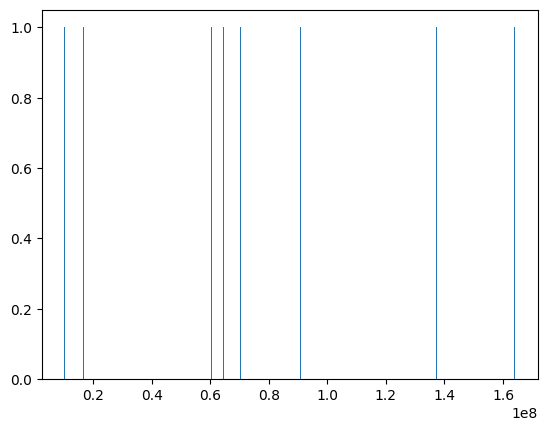

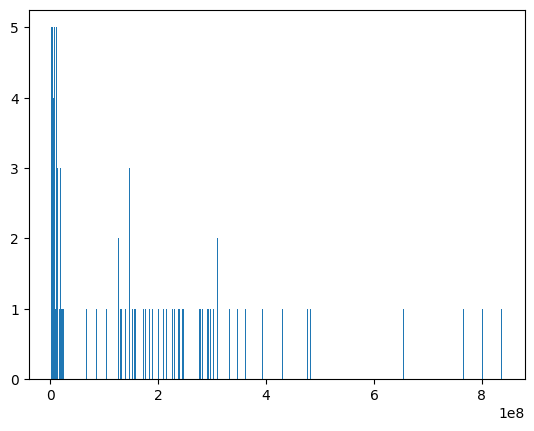

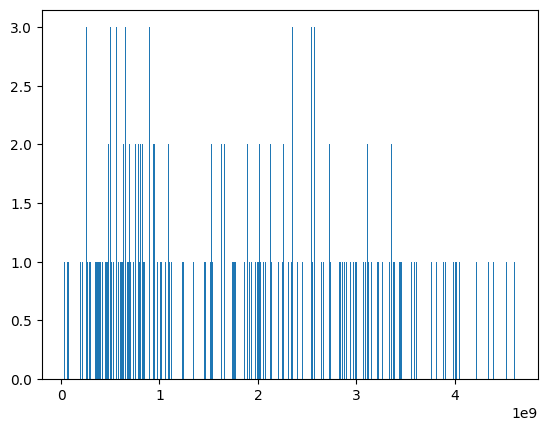

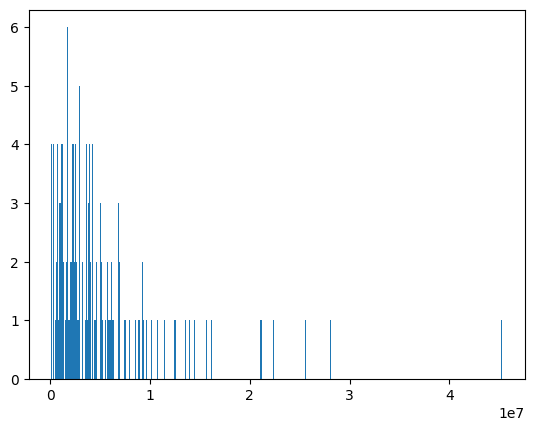

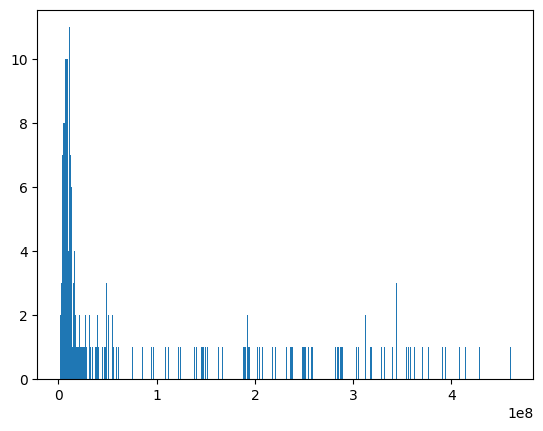

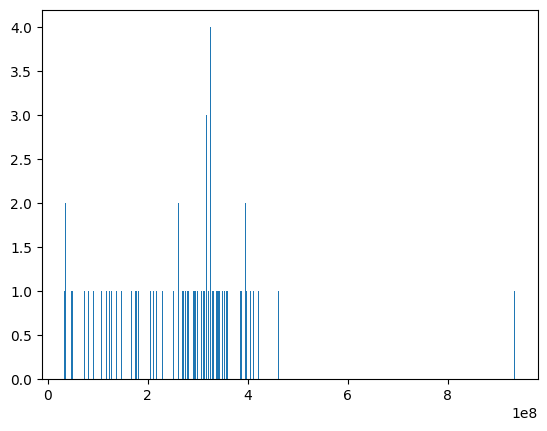

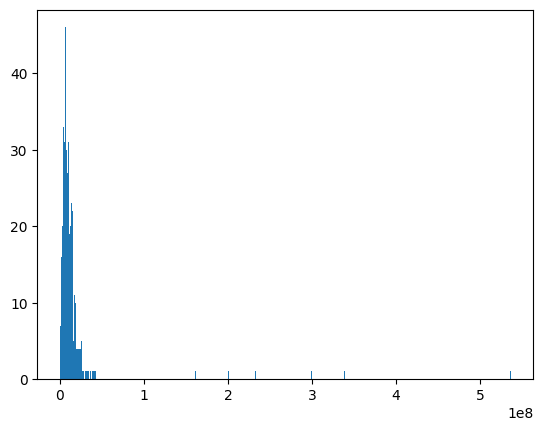

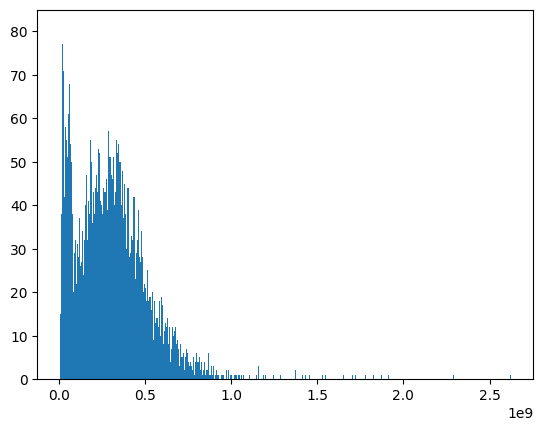

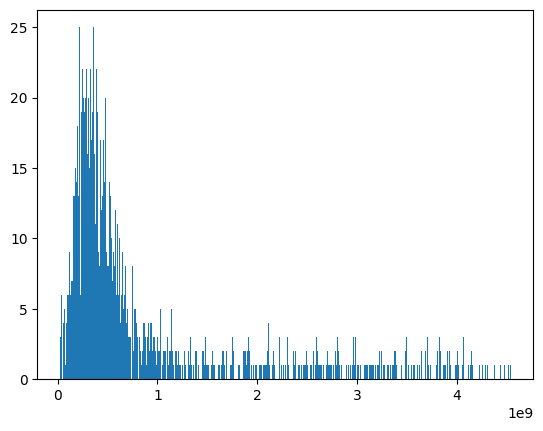

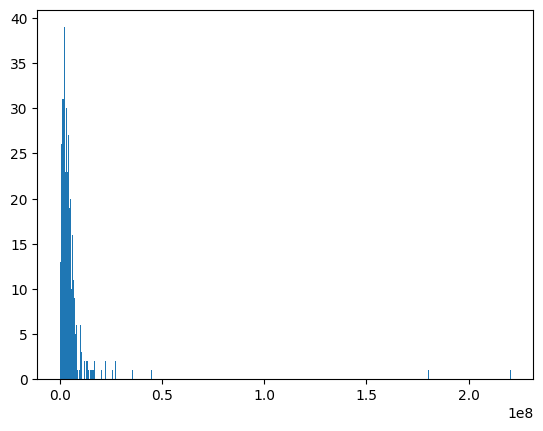

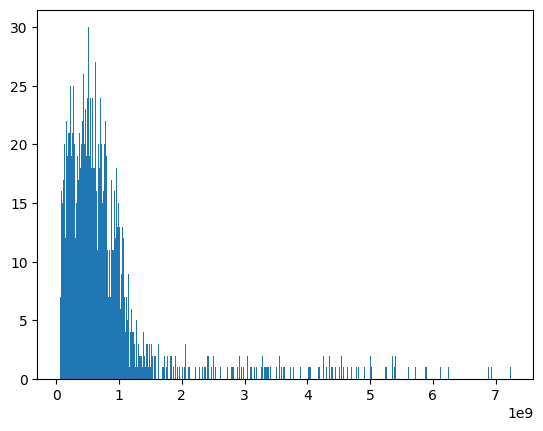

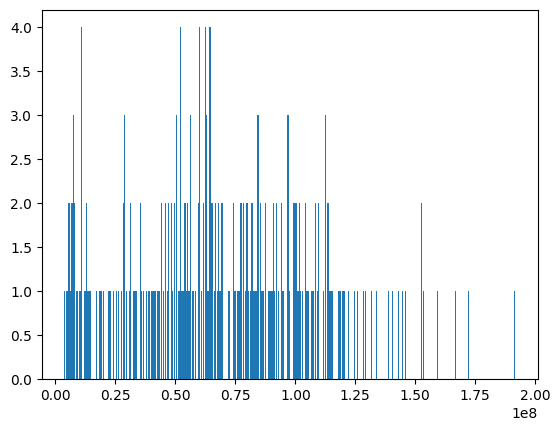

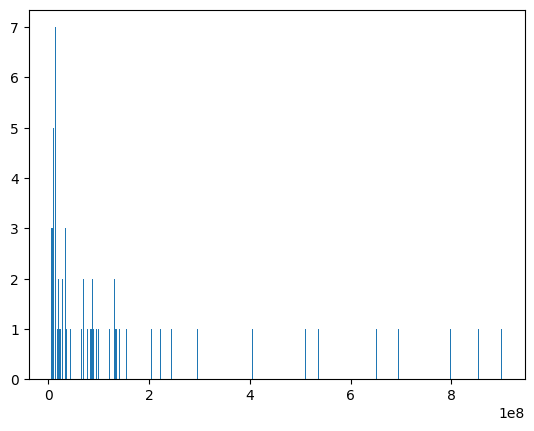

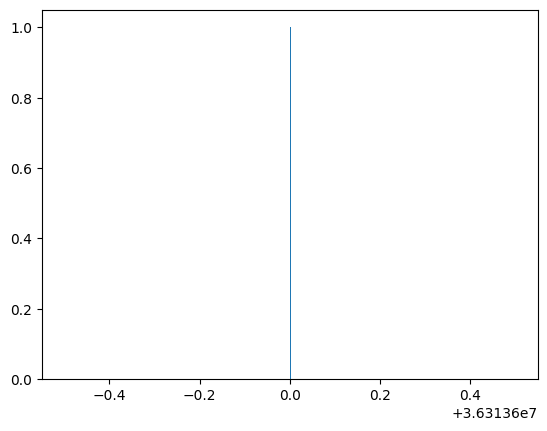

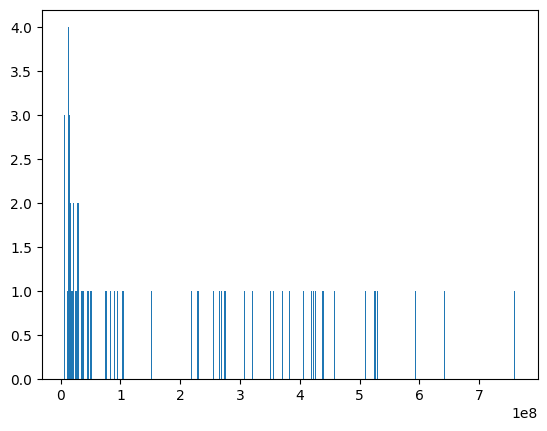

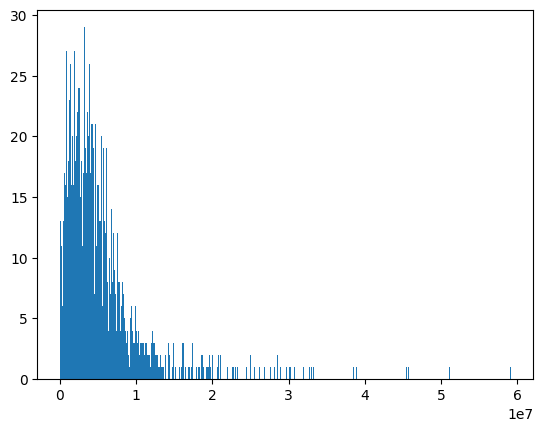

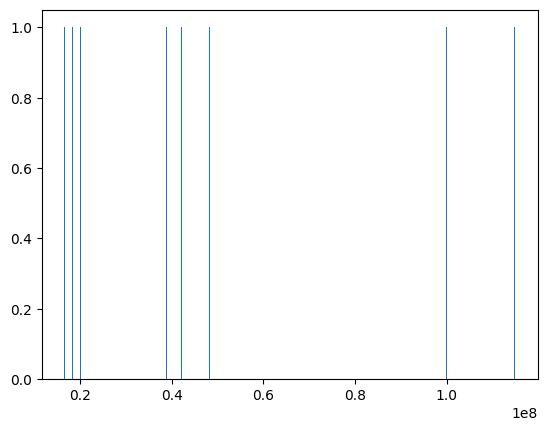

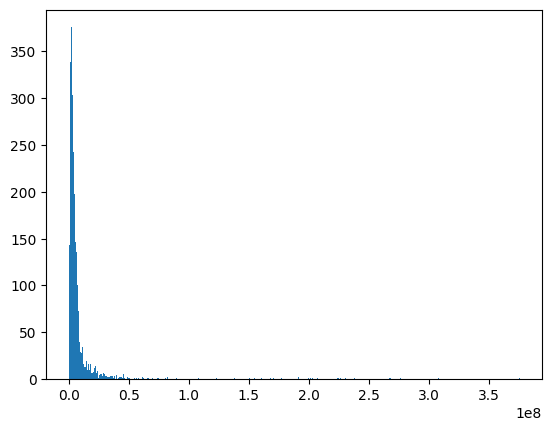

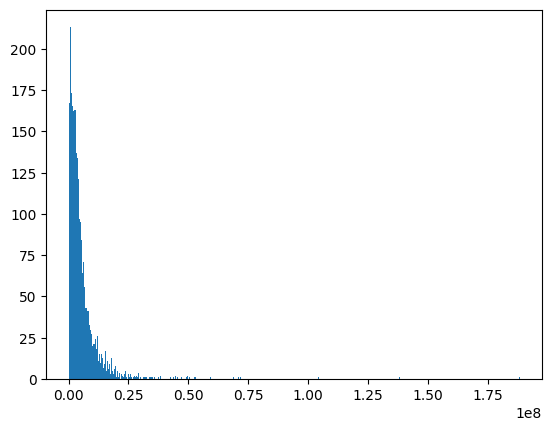

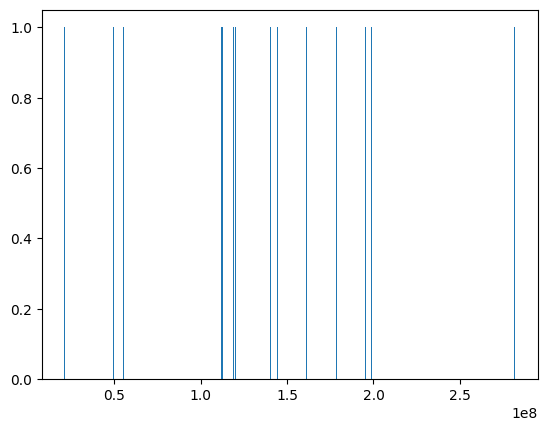

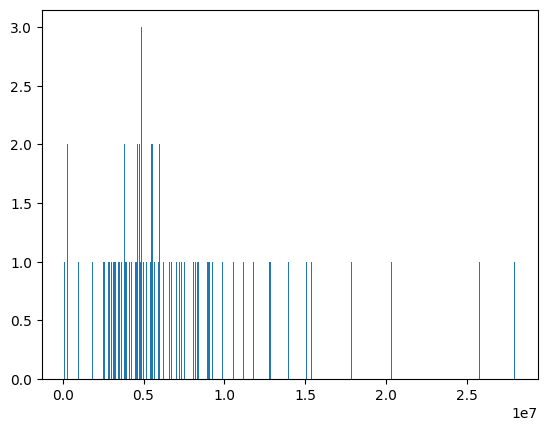

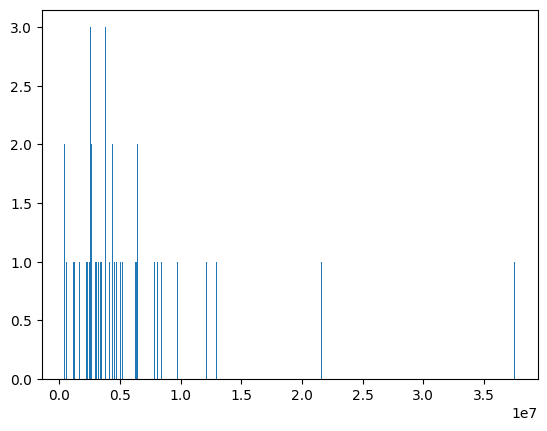

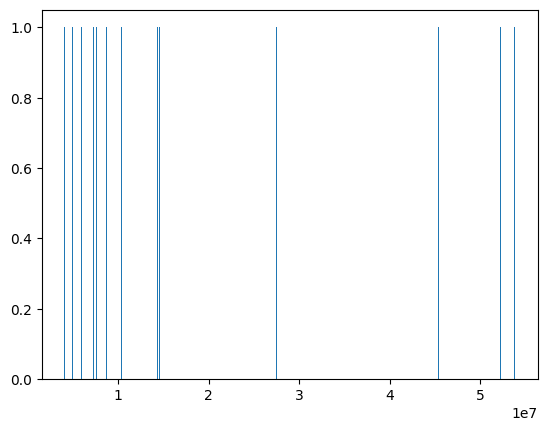

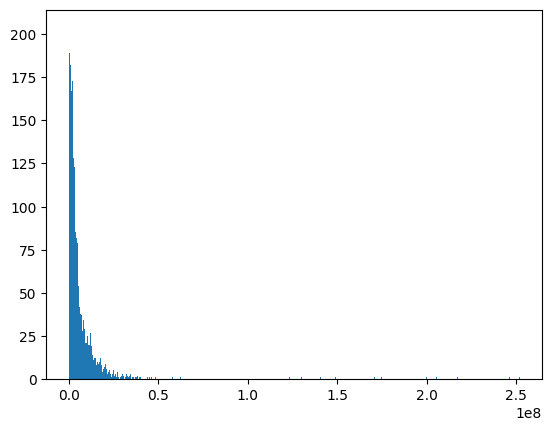

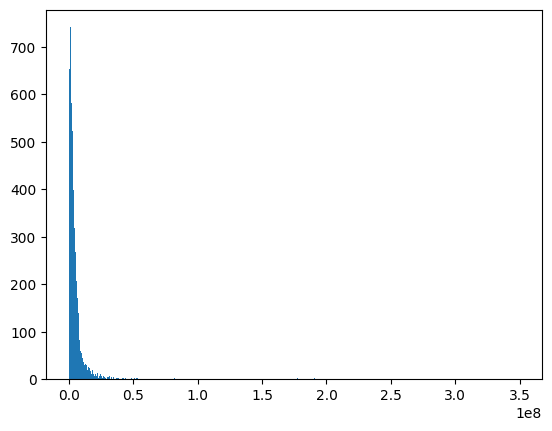

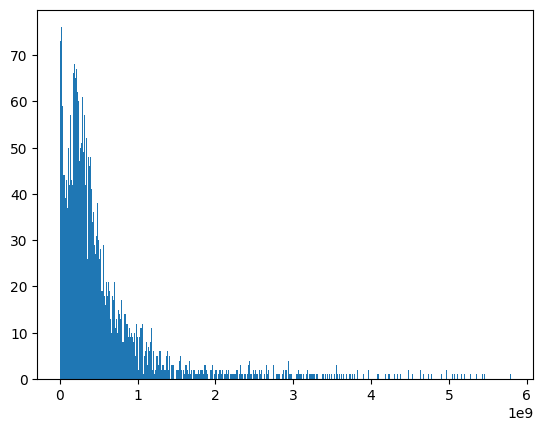

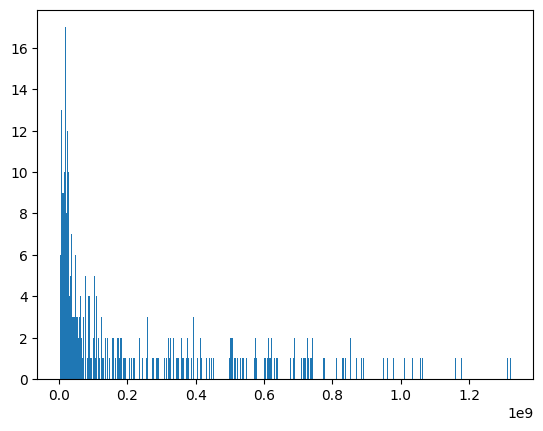

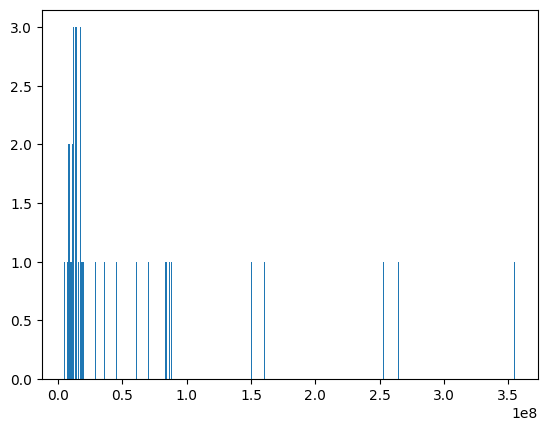

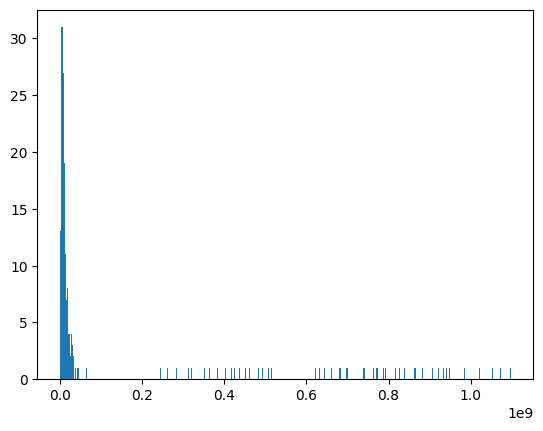

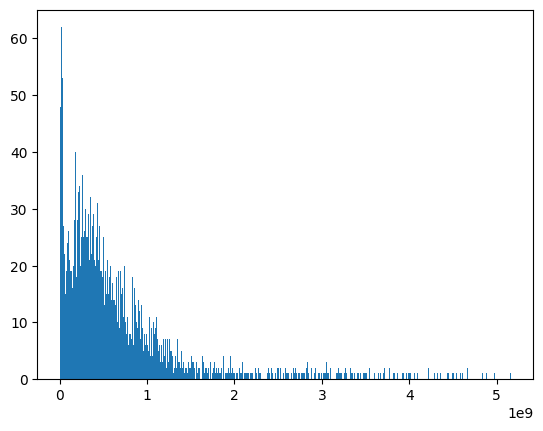

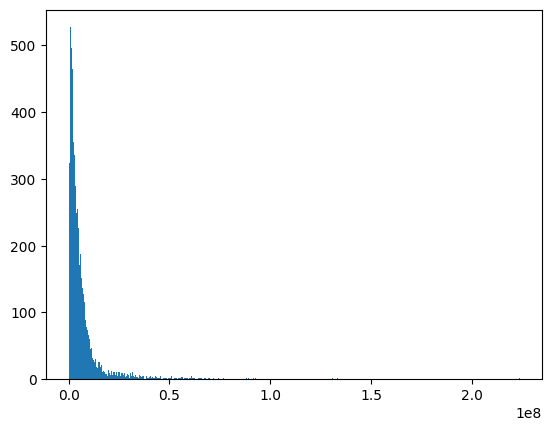

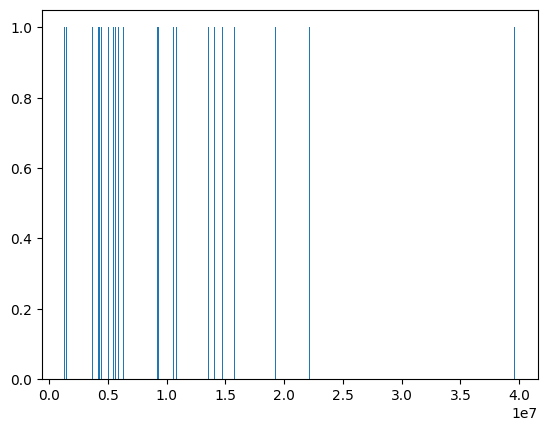

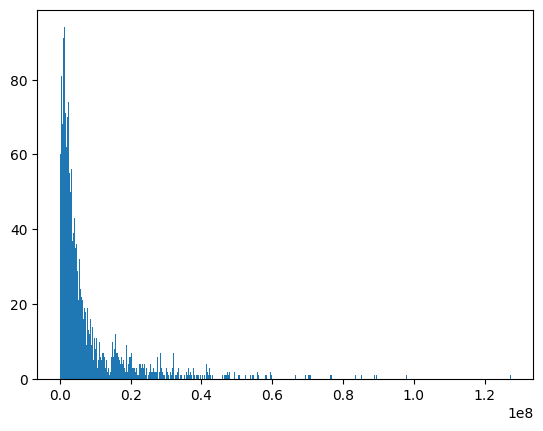

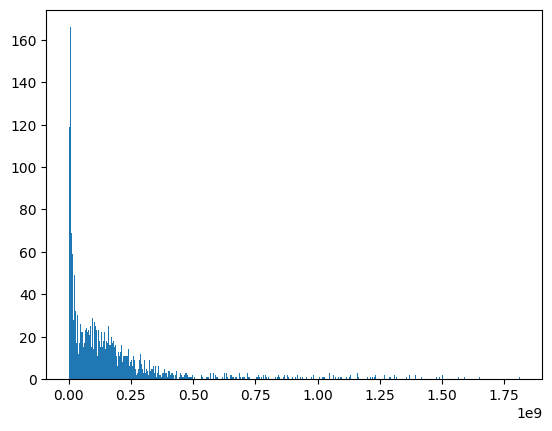

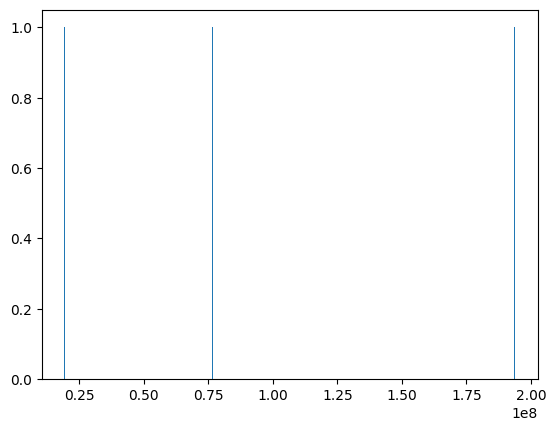

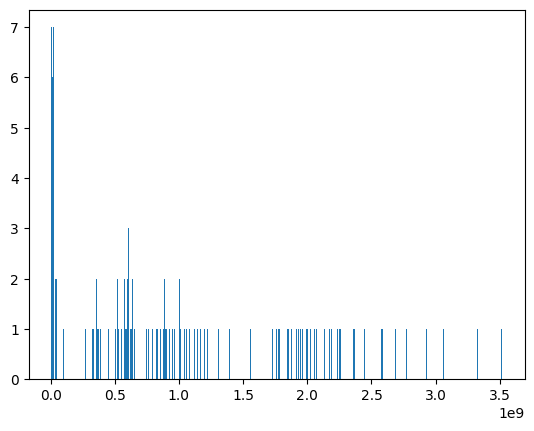

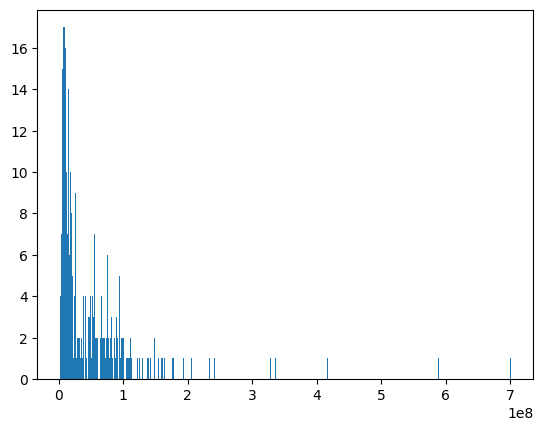

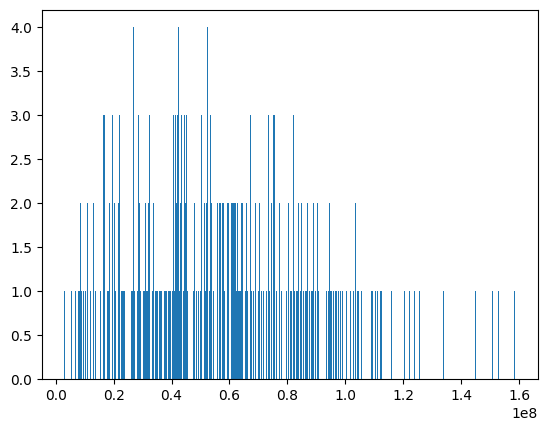

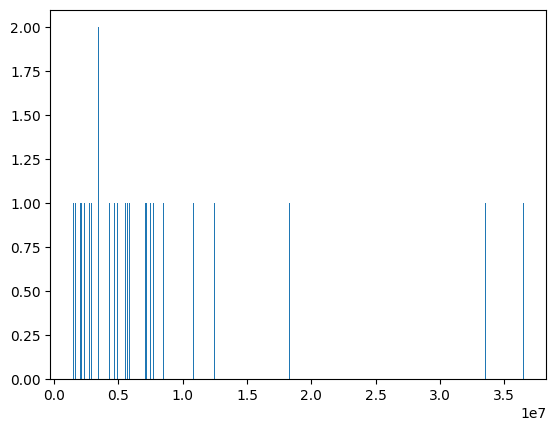

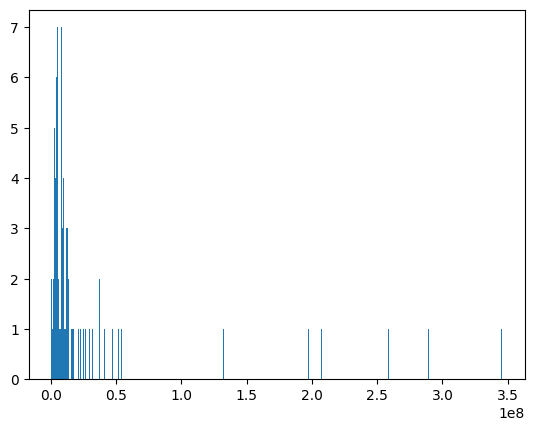

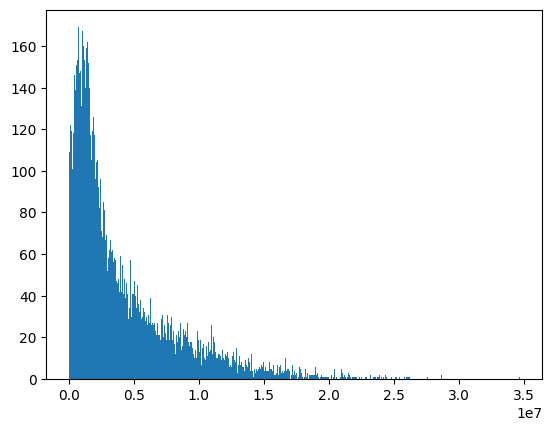

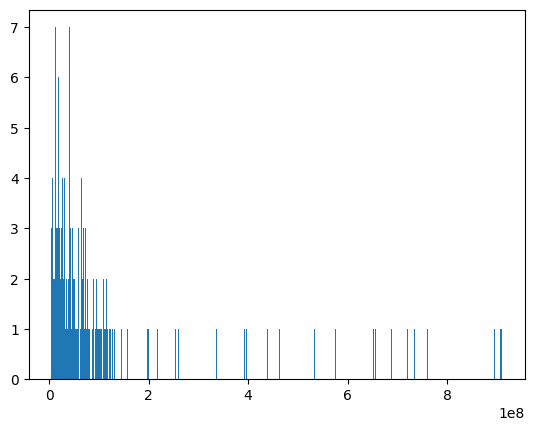

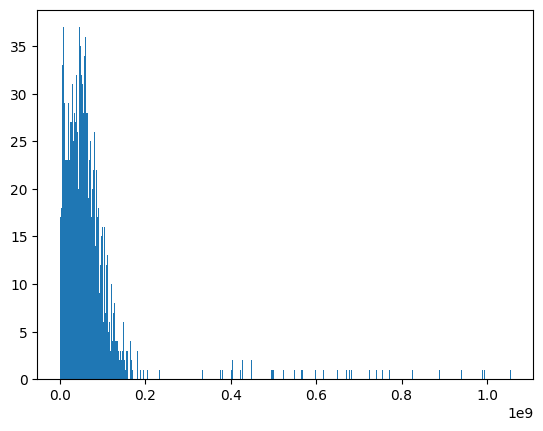

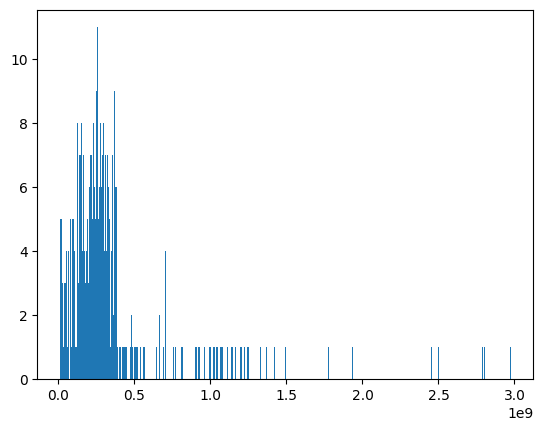

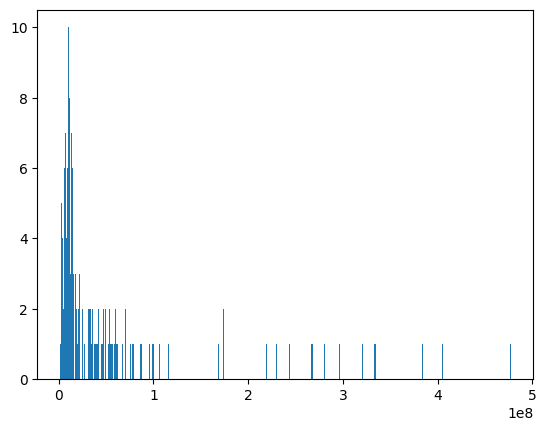

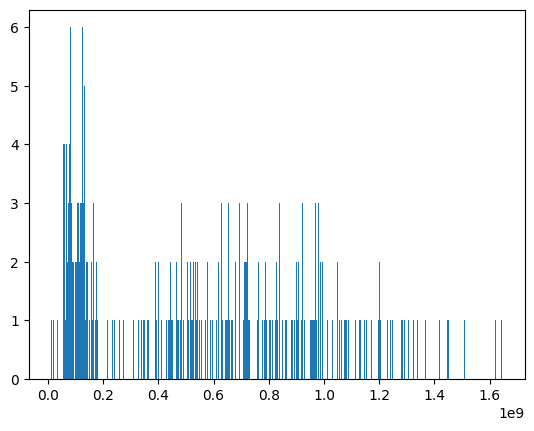

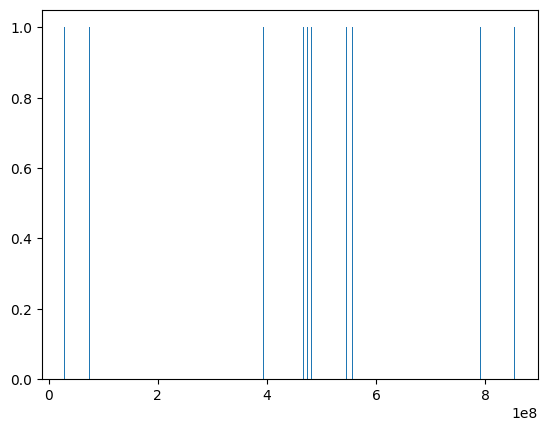

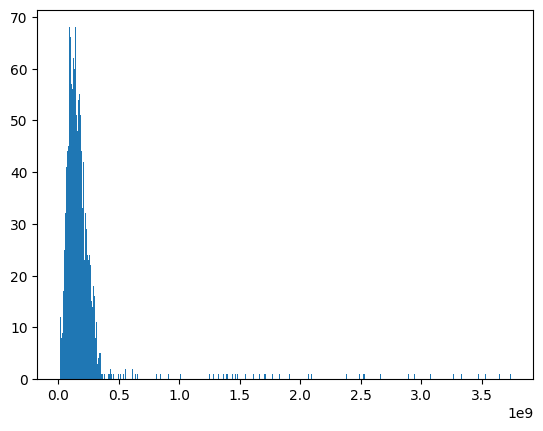

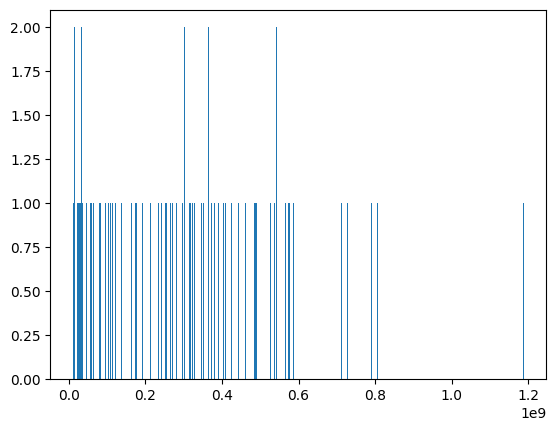

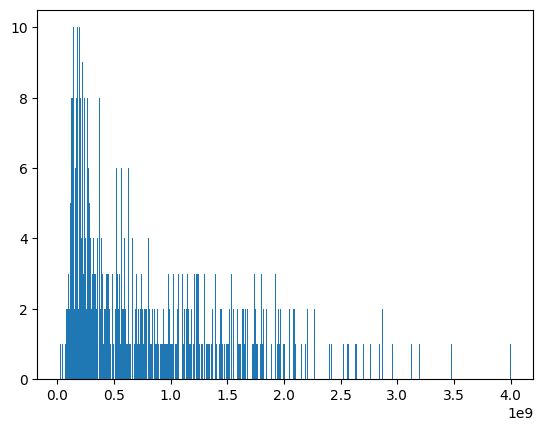

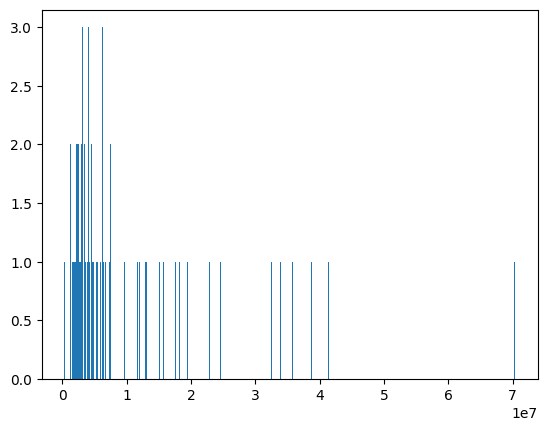

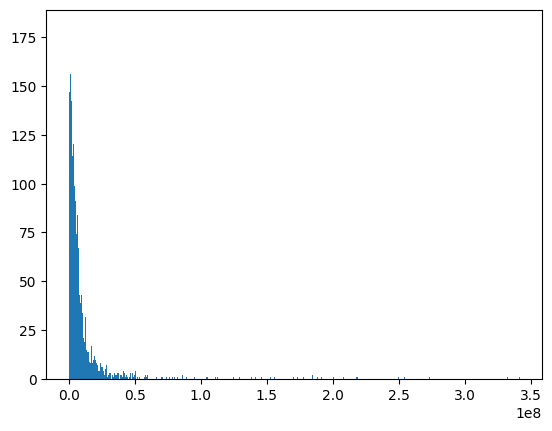

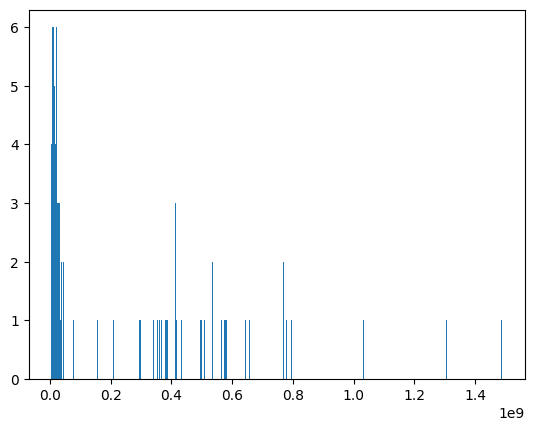

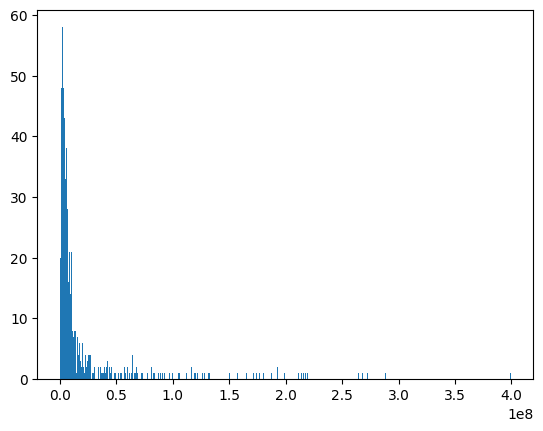

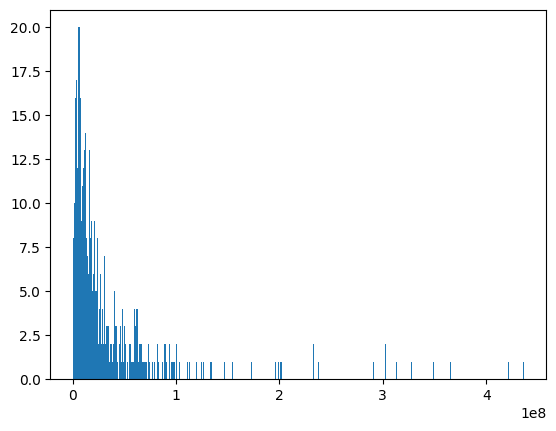

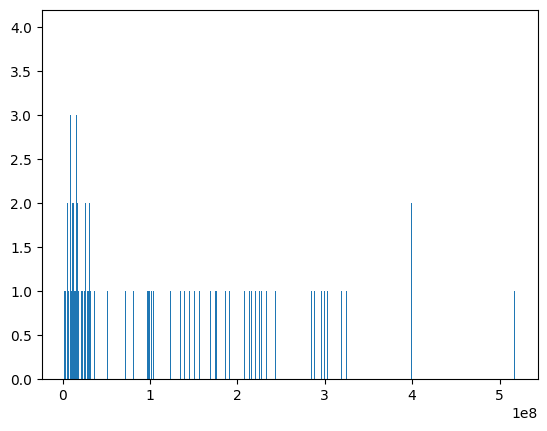

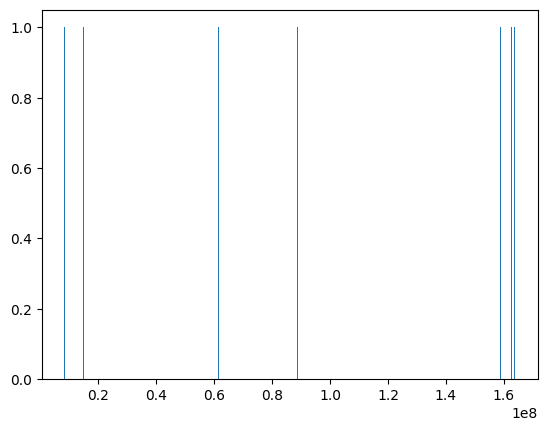

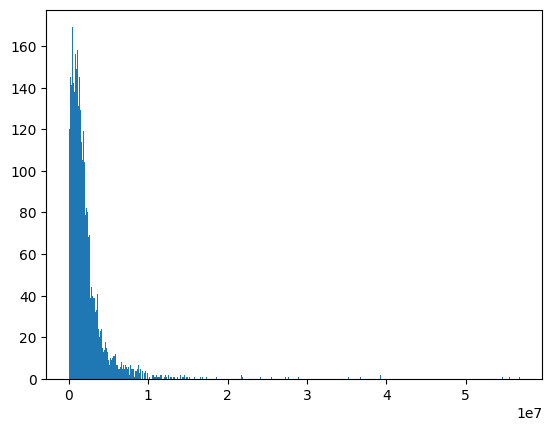

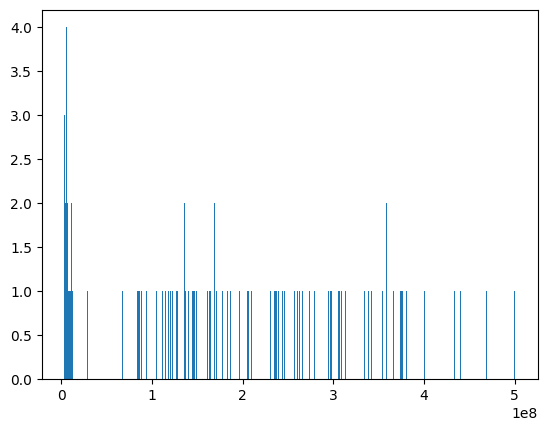

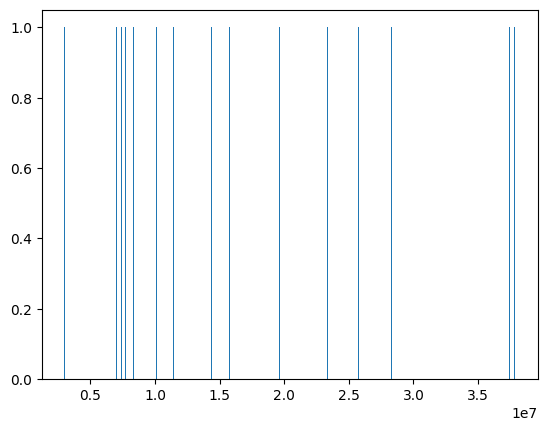

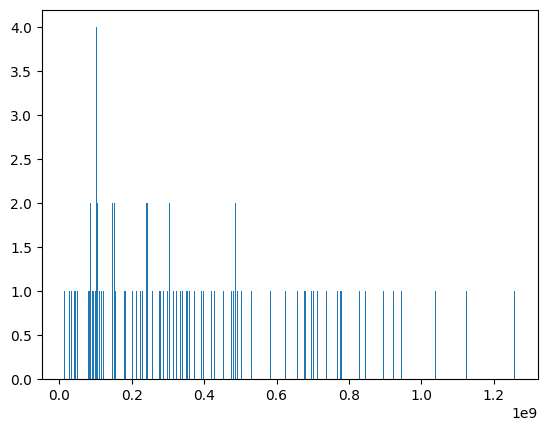

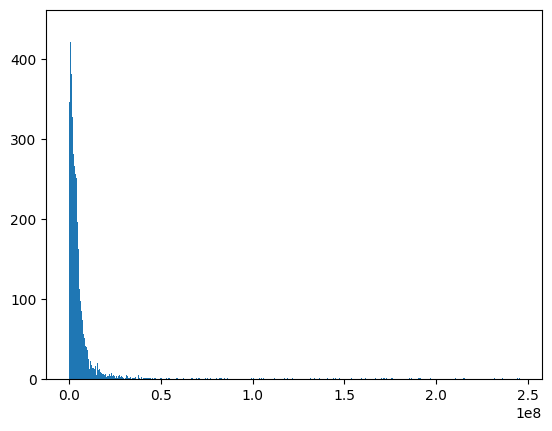

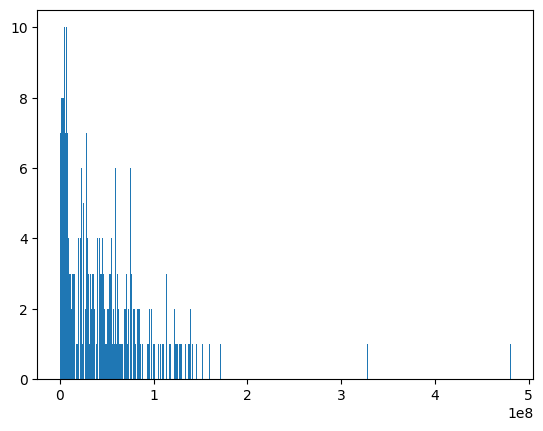

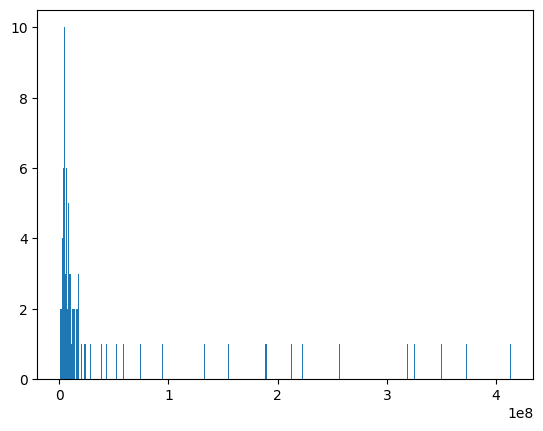

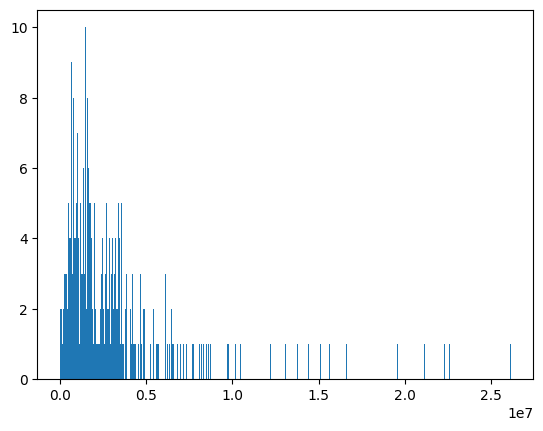

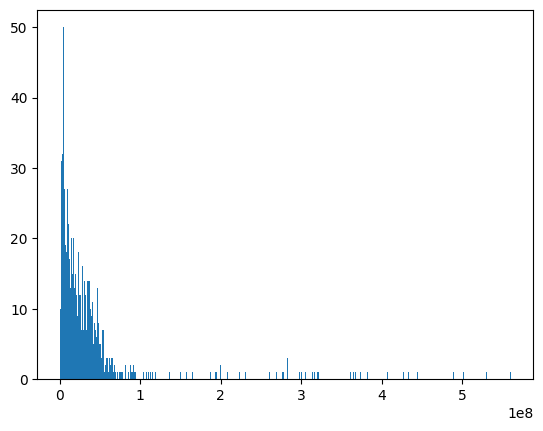

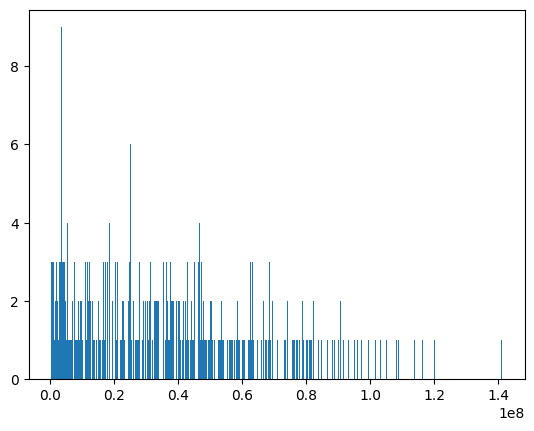

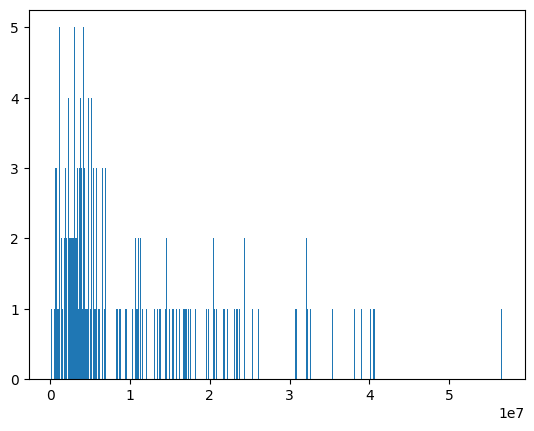

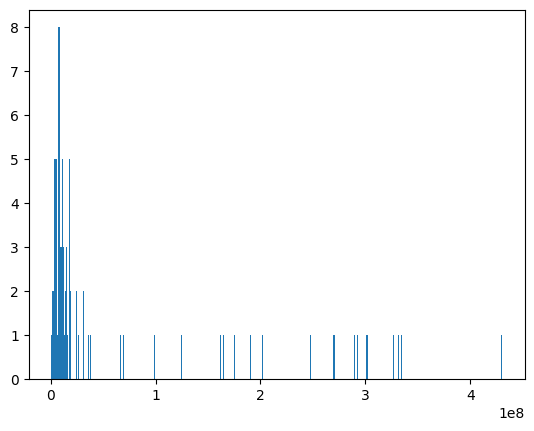

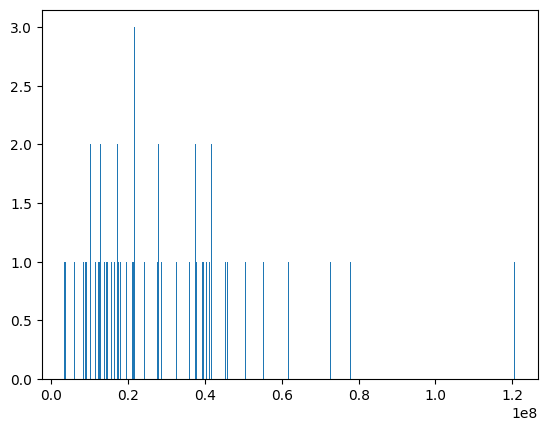

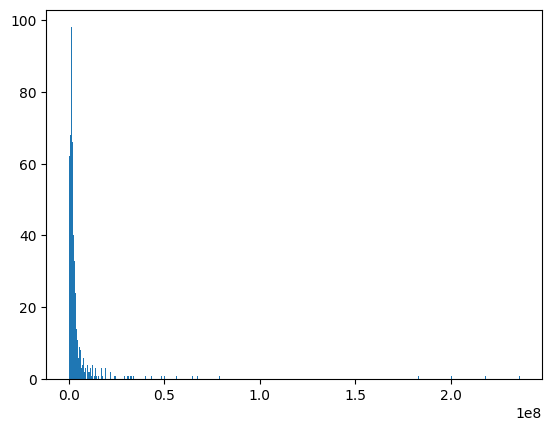

In [270]:
for i, group in enumerate(clu_group):
    if group == "good":
        scores = all_spike_scores[all_spike_labels==i]
        real_scores = scores[~np.isnan(scores)]
        if len(real_scores) > 0:
            plt.hist(real_scores, bins=500)
            plt.show()

In [244]:
'''
Export results + post-process
- phy compatible format
- and/or SC automated curation method?
- ultimately match key files to existing data (e.g. wfStruct)
'''
# create a sorting analyzer
analyzer = si.create_sorting_analyzer(
    sorting=combined_sorting,
    recording=recording,
    folder="analyzer",
)

# compute things for phy
analyzer.compute(['random_spikes', 'waveforms', 'templates', 'noise_levels'])
_ = analyzer.compute('principal_components', n_components = 5, mode="by_channel_local")
_ = analyzer.compute("spike_amplitudes")
_ = analyzer.compute("unit_locations")
_ = analyzer.compute("template_similarity")

estimate_sparsity (no parallelization):   0%|          | 0/2740 [00:00<?, ?it/s]

compute_waveforms (no parallelization):   0%|          | 0/2740 [00:00<?, ?it/s]

Fitting PCA:   0%|          | 0/323 [00:00<?, ?it/s]

Projecting waveforms:   0%|          | 0/323 [00:00<?, ?it/s]

spike_amplitudes (no parallelization):   0%|          | 0/2740 [00:00<?, ?it/s]

C:\Users\Isabel\miniconda3\envs\spike_sort\Lib\site-packages\spikeinterface\postprocessing\template_similarity.py:345: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  overlapping_ids = overlapping_j_list[i]


FileExistsError: C:\Users\Isabel\Documents\data_temp\SLV132_250310\SLV132_250310_122522\dartsort_temp already exists

In [245]:
# export to phy - todo
sexp.export_to_phy(analyzer, output_folder=f'{ds_folder}/.phy')

write_binary_recording (no parallelization):   0%|          | 0/2740 [00:00<?, ?it/s]

extract PCs (no parallelization):   0%|          | 0/2740 [00:00<?, ?it/s]

Run:
phy template-gui  C:\Users\Isabel\Documents\data_temp\SLV132_250310\SLV132_250310_122522\dartsort_temp\.phy\params.py


In [ ]:
'''
Notes from phy
- check that amplitude scaling is within units and consistent across recording
- only "good" units or at least exclude noise
'''